In [1]:
import os
import sys
import torch
from matplotlib import pyplot as plt
from typing import Any, Dict
from pathlib import Path
from lib import config_utils
from lib import data_utils
from lib import visutils
from lib.eval_tools import (
    Imputation,
    visualize_att_for_one_head_across_time,
    visualize_att_for_target_t_across_heads
)

###

### Fonctions utiles

In [2]:
def get_sample(
    dataloader: torch.utils.data.dataloader.DataLoader,
    sample_index: int
) -> Dict[str, Any]:
    batch = dataloader.dataset.__getitem__(sample_index)
    # Introduce the batch dimension (required for the forward pass)
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0)
        elif isinstance(v, int):
            batch[k] = [v]
    return batch

### Chargement des données

In [3]:
config_file = Path("configs/inference_circa.yaml")
run_mode = "test"

if not config_file.exists():
    raise FileNotFoundError(f'Cannot find the test configuration file: {config_file.as_posix()}\n')

config = config_utils.read_config(config_file)
dset = data_utils.get_dataset(config, phase=run_mode)
dataloader = torch.utils.data.DataLoader(
    dataset=dset, batch_size=1, shuffle=False, num_workers=8, drop_last=False
)

### Chargement du modèle

In [4]:
import os
from pathlib import Path
from typing import Any, Dict

import torch
from matplotlib import pyplot as plt

from lib import config_utils, data_utils, visutils

config_file = Path("configs/inference_circa.yaml")
run_mode = "test"

if not config_file.exists():
    raise FileNotFoundError(f"Cannot find the test configuration file: {config_file.as_posix()}\n")

config = config_utils.read_config(config_file)
dset = data_utils.get_dataset(config, phase=run_mode)
dataloader = torch.utils.data.DataLoader(dataset=dset, batch_size=1, shuffle=False, num_workers=8, drop_last=False)

checkpoint = Path("checkpoints/utilise_earthnet2021.pth")


In [5]:
utilise = Imputation(
    config_file,
    method="utilise",
    checkpoint=checkpoint,
)

Checkpoint 'checkpoints/utilise_earthnet2021.pth' loaded.
Chosen epoch: 982



/home/SPeillet/pac_rpg/cloud_reconstructions/U-TILISE/lib/eval_tools.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(self.checkpoint)


### Visualisation résultats

4


Text(0.5, 1.0, 'U-TILISE imputation')

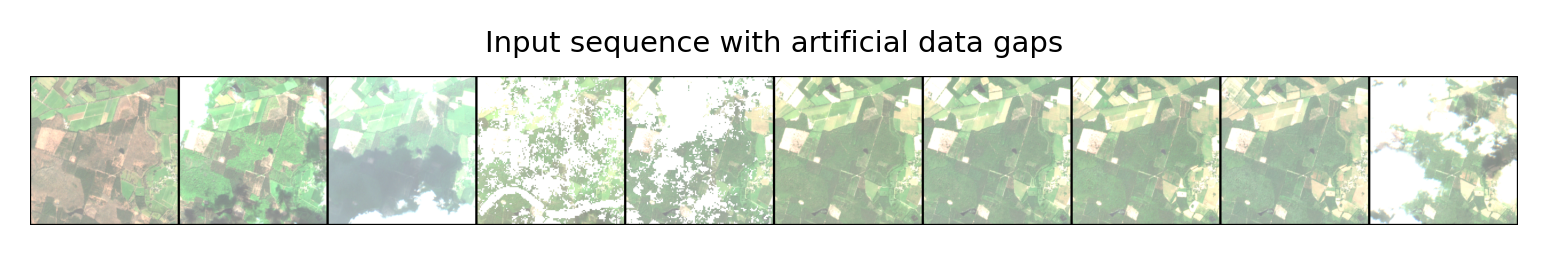

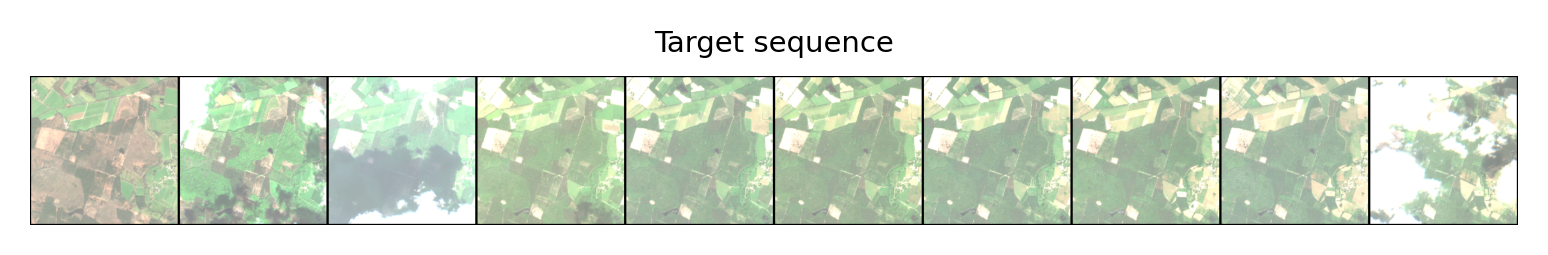

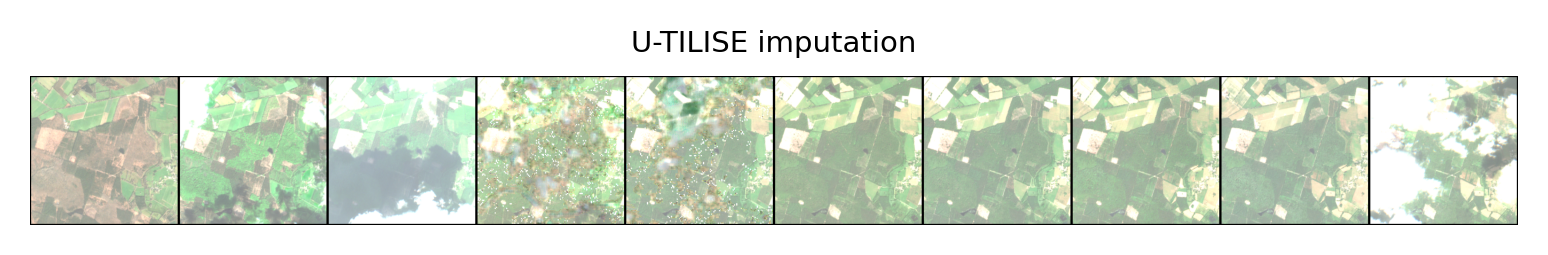

In [12]:
# Get a data sample
batch = get_sample(dataloader, sample_index=6)

# Use U-TILISE to impute the satellite image time series
_, y_pred = utilise.impute_sample(batch)

# Let's visualize the sequences
brightness_factor = 5
indices_rgb = batch['c_index_rgb'][0]

fig = visutils.sequence2gallery(batch['x'][0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('Input sequence with artificial data gaps', fontsize=7)

fig = visutils.sequence2gallery(batch['y'][0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('Target sequence', fontsize=7)

fig = visutils.sequence2gallery(y_pred[0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('U-TILISE imputation', fontsize=7)